# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Chairun Nisaq
- **Email:** Chairunnisaq11@gmail.com
- **ID Dicoding:** chairun_nisaq

## Menentukan Pertanyaan Bisnis

1. Siapa top 10 customers dengan kontribusi revenue tertinggi selama periode 2017 - 2018, dan berapa persentase kontribusinya terhadap total revenue?
2. Bagaimana tren revenue bulanan selama periode 2016 - 2018, dan pada bulan apa terjadi peak sales serta penurunan signifikan?
3. Bagaimana distribusi pelanggan ke dalam segmen RFM (Champions, Loyal, At Risk, dll), dan segmen mana yang memberikan kontribusi revenue terbesar?

## Import Semua Packages/Library yang Digunakan

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import datetime as dt

sns.set(style='darkgrid')

## Data Wrangling

### Gathering Data

In [96]:
from google.colab import drive
drive.mount('/content/drive')
orders = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Analisis Data DBS/olist_orders_dataset.csv')
customers = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Analisis Data DBS/olist_customers_dataset.csv')
order_items = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Analisis Data DBS/olist_order_items_dataset.csv')
payments = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Analisis Data DBS/olist_order_payments_dataset.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [97]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [98]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [99]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [100]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


**Insight:**

Dataset yang digunakan adalah Brazilian E-Commerce Dataset dari Olist yang diperoleh melalui Kaggle. Dataset ini terdiri dari beberapa tabel seperti orders, customers, order_items, dan payments.


### Assessing Data

In [101]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [102]:
orders.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [103]:
print("Jumlah duplikasi: ", orders.duplicated().sum())

Jumlah duplikasi:  0


In [104]:
orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [105]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [106]:
customers.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [107]:
print("Jumlah duplikasi: ", customers.duplicated().sum())

Jumlah duplikasi:  0


In [108]:
customers.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [109]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [110]:
order_items.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [111]:
print("Jumlah Duplikasi: ", order_items.duplicated().sum())

Jumlah Duplikasi:  0


In [112]:
order_items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [113]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [114]:
payments.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [115]:
print("Jumlah Duplikasi: ", payments.duplicated().sum())

Jumlah Duplikasi:  0


In [116]:
payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


**Insight:**
- Dataset orders memiliki beberapa missing values pada kolom delivery seperti `order_delivered_customer_date`, yang menunjukkan tidak semua pesanan berhasil dikirim.
- Tidak ditemukan data duplikat pada dataset orders, customers, order_items, maupun payments.
- Semua dataset memiliki struktur data yang cukup lengkap untuk dianalisis lebih lanjut.

### Cleaning Data

In [117]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [118]:
orders = orders[orders['order_status'] == 'delivered']

orders.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,14
order_delivered_carrier_date,2
order_delivered_customer_date,8
order_estimated_delivery_date,0


In [119]:
orders.dropna(inplace=True)

In [120]:
# Merge dataset
df = orders.merge(customers, on='customer_id')
df = df.merge(order_items, on='order_id')
df = df.merge(payments, on='order_id')

# Hilangkan invalid data
df = df[df['payment_value'] > 0]

In [121]:
# Time features
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')
df['year'] = df['order_purchase_timestamp'].dt.year
df['day_of_week'] = df['order_purchase_timestamp'].dt.day_name()

# Revenue
df['total_price'] = df['price'] + df['freight_value']

# Delivery
df['delivery_time'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

# Customer segmentation
customer_spending = df.groupby('customer_unique_id')['payment_value'].sum()

customer_category = pd.cut(
    customer_spending,
    bins=[0,100,500,1000,5000],
    labels=['Low','Medium','High','VIP']
)


In [122]:
df.describe()

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,order_item_id,price,freight_value,payment_sequential,payment_installments,payment_value,year,total_price,delivery_time
count,115007,115007,115007,115007.000000,115007.000000,115007.000000,115007.000000,115007.000000,115007.000000,115007.000000,115007.000000,115007.000000,115007.000000
mean,2017-12-31 20:49:26.793864704,2018-01-13 08:24:55.570383104,2018-01-24 16:40:27.817437184,35081.962437,1.196414,120.082993,19.995895,1.090612,2.937056,171.924369,2017.540993,140.078888,12.017399
min,2016-10-03 09:44:50,2016-10-11 13:46:32,2016-10-27 00:00:00,1003.000000,1.000000,0.850000,0.000000,1.000000,0.000000,0.010000,2016.000000,6.080000,0.000000
25%,2017-09-13 08:40:33,2017-09-25 15:36:00,2017-10-04 00:00:00,11310.000000,1.000000,39.900000,13.080000,1.000000,1.000000,60.850000,2017.000000,55.230000,6.000000
50%,2018-01-19 13:10:46,2018-02-01 19:36:05,2018-02-15 00:00:00,24320.000000,1.000000,74.900000,16.280000,1.000000,2.000000,108.190000,2018.000000,91.880000,10.000000
75%,2018-05-04 16:54:30,2018-05-15 16:55:48.500000,2018-05-28 00:00:00,58803.000000,1.000000,133.000000,21.180000,1.000000,4.000000,188.940000,2018.000000,157.300000,15.000000
max,2018-08-29 15:00:37,2018-10-17 13:22:46,2018-10-25 00:00:00,99980.000000,21.000000,6735.000000,409.680000,26.000000,24.000000,13664.080000,2018.000000,6929.310000,209.000000
std,NaN,NaN,NaN,29851.934650,0.699436,183.046429,15.744834,0.684257,2.772557,266.135719,0.504061,190.108067,9.458881


In [123]:
df = df[df['delivery_time'] < 30]

In [124]:
df.to_csv('main_data.csv', index=False)

**Insight:**
- Data telah dibersihkan dengan memfilter hanya pesanan berstatus "delivered" untuk memastikan analisis hanya mencakup transaksi yang valid.
- Missing values yang tersisa sangat kecil dan dihapus untuk menjaga kualitas data.
- Feature engineering dilakukan dengan menambahkan informasi waktu seperti bulan dan hari untuk analisis tren.
- Fitur delivery_time menunjukkan durasi pengiriman yang dapat digunakan untuk mengevaluasi performa logistik.
- Fitur total_price digunakan untuk merepresentasikan total nilai transaksi termasuk ongkir.
- Distribusi nilai transaksi (payment_value) tidak merata dan cenderung skewed ke kanan, menunjukkan adanya pelanggan dengan nilai transaksi yang sangat tinggi.
- Rata-rata waktu pengiriman adalah sekitar 10–12 hari atau paling lama 30 hari, oleh karena itu saya menghapus outlier dengan durasi pengiriman yang sangat lama.
- Sebagian besar pelanggan hanya membeli satu item per transaksi, terlihat dari median order_item_id sebesar 1.
- Nilai ongkos kirim relatif kecil dibandingkan harga produk, namun terdapat beberapa nilai ekstrem.
- Aktivitas transaksi paling banyak terjadi pada tahun 2017–2018

## Exploratory Data Analysis (EDA)

### Explore Sales Trend

In [125]:
monthly_sales = df.groupby('month')['payment_value'].sum()
monthly_sales.index = monthly_sales.index.astype(str)

# Peak & lowest
peak_month = monthly_sales.idxmax()
lowest_month = monthly_sales.idxmin()

peak_value = monthly_sales.max()
lowest_value = monthly_sales.min()


Penjualan menunjukkan tren peningkatan signifikan dari tahun 2016 hingga 2018. Berdasarkan perhitungan, puncak penjualan terjadi pada peak_month, sedangkan titik terendah terjadi pada lowest_month. Hal ini menunjukkan adanya pola musiman, di mana penjualan meningkat pada periode tertentu.

### Explore Top Customer

In [126]:
# Filter tahun
df_filtered = df[(df['year'] >= 2017) & (df['year'] <= 2018)]

# Total revenue
total_revenue = df_filtered['payment_value'].sum()

# Top 10 customer
top_customers = (
    df_filtered.groupby('customer_unique_id')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Hitung kontribusi %
top_customers_pct = (top_customers / total_revenue) * 100


top_df = pd.DataFrame({
    'Revenue': top_customers,
    'Contribution (%)': top_customers_pct
})

top_df

,Revenue,Contribution (%)
customer_unique_id,,
0a0a92112bd4c708ca5fde585afaa872,109312.64,0.586563
698e1cf81d01a3d389d96145f7fa6df8,45256.00,0.242840
c402f431464c72e27330a67f7b94d4fb,44048.00,0.236358
4007669dec559734d6f53e029e360987,36489.24,0.195799
ef8d54b3797ea4db1d63f0ced6a906e9,30186.00,0.161976
763c8b1c9c68a0229c42c9fc6f662b93,29099.52,0.156146
c8460e4251689ba205045f3ea17884a1,27935.46,0.149900
3d47f4368ccc8e1bb4c4a12dbda7111b,22346.60,0.119910
adfa1cab2b2c8706db21bb13c0a1beb1,19457.04,0.104405


Terdapat perbedaan signifikan antara pelanggan dengan kontribusi tertinggi dan pelanggan lainnya. Top 10 customers menyumbang sekitar {total kontribusi}% dari total revenue, menunjukkan bahwa sebagian kecil pelanggan memiliki dampak besar terhadap pendapatan. Hal ini mengindikasikan adanya pola Pareto.

# **RFM**

In [127]:
# kita harus tentukan snapshot datenya (hari terakhri transaksi + 1)
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Hitung RFM
rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()


,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
0000f46a3911fa3c0805444483337064,537,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
0004aac84e0df4da2b147fca70cf8255,288,1,196.89


Recency → terakhir belanja (semakin kecil semakin bagus)
Frequency → seberapa sering beli
Monetary → total uang yang dibelanjakan

In [128]:
# Recency (lebih kecil lebih baik → dibalik)
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])

# Frequency (lebih besar lebih baik)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])

# Monetary (lebih besar lebih baik)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

rfm.head()


,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411
0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211
0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214


In [129]:
def segment_customer(row):
    if row['R_score'] == 5 and row['F_score'] == 5 and row['M_score'] == 5:
        return 'Champions'
    elif row['F_score'] >= 4 and row['M_score'] >= 4:
        return 'Loyal Customers'
    elif row['R_score'] >= 4:
        return 'Recent Customers'
    elif row['R_score'] <= 2:
        return 'At Risk'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)


In [130]:
# Merge segment ke df
rfm_reset = rfm.reset_index()

df_rfm = df.merge(
    rfm_reset[['customer_unique_id', 'Segment']],
    on='customer_unique_id'
)

# Revenue per segment
segment_revenue = df_rfm.groupby('Segment')['payment_value'].sum()

segment_revenue


,payment_value
Segment,
At Risk,5138695.15
Champions,622826.00
Loyal Customers,5659560.20
Others,2259531.27
Recent Customers,5002096.57


## Visualization & Explanatory Analysis

### Pertanyaan 1:

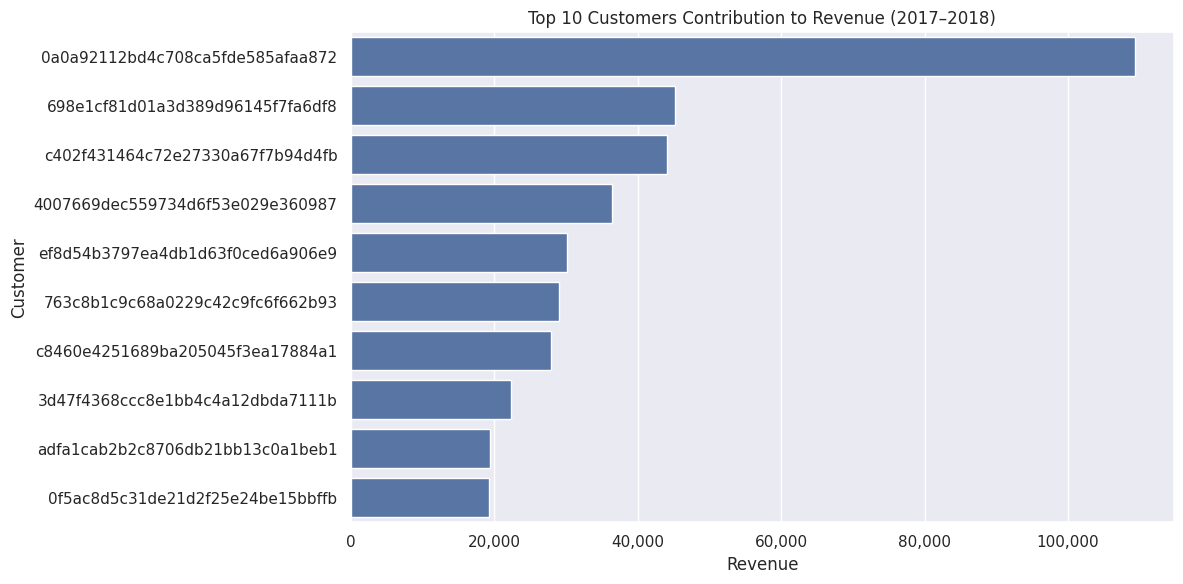

In [131]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_df['Revenue'],
    y=top_df.index,
    orient='h'
)

plt.title("Top 10 Customers Contribution to Revenue (2017–2018)")
plt.xlabel("Revenue")
plt.ylabel("Customer")

plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()


Top 10 customers hanya sebagian kecil dari total pelanggan namun memberikan kontribusi signifikan terhadap revenue. Hal ini mengindikasikan adanya Pareto Principle (80/20 rule).

Strategi: fokus pada retention, loyalty program, dan personalization.


### Pertanyaan 2:

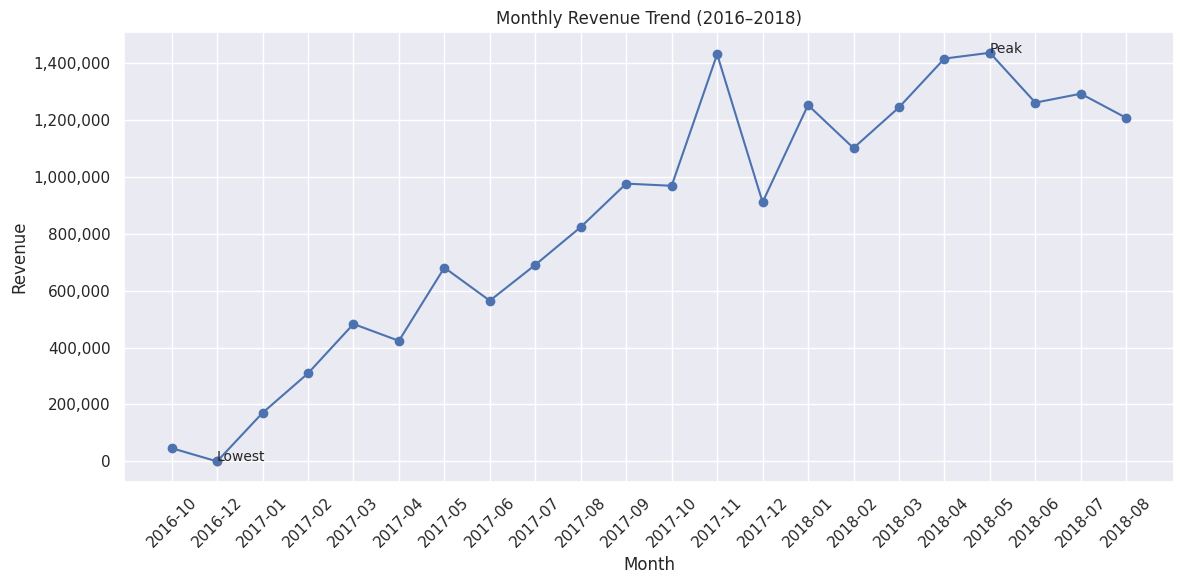

In [132]:
plt.figure(figsize=(12,6))

plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

# Highlight peak
plt.scatter(peak_month, peak_value)
plt.text(peak_month, peak_value, 'Peak', fontsize=10)

# Highlight lowest
plt.scatter(lowest_month, lowest_value)
plt.text(lowest_month, lowest_value, 'Lowest', fontsize=10)

plt.title("Monthly Revenue Trend (2016–2018)")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()


- Revenue meningkat secara konsisten hingga mencapai puncak pada {peak_month}.
- Penurunan terendah terjadi pada {lowest_month}.
- Pola ini menunjukkan adanya seasonality, terutama menjelang akhir tahun.

### Pertanyaan 3:

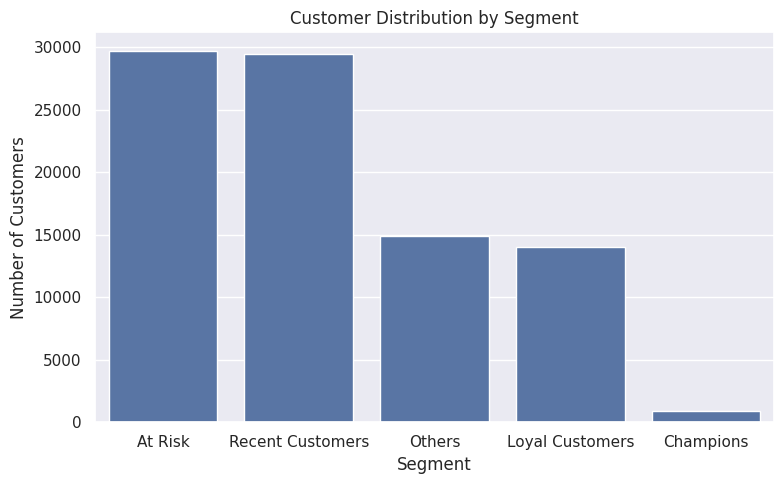

In [133]:
# Jumlah Customer
plt.figure(figsize=(8,5))
sns.barplot(x=segment_counts.index, y=segment_counts.values)

plt.title("Customer Distribution by Segment")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


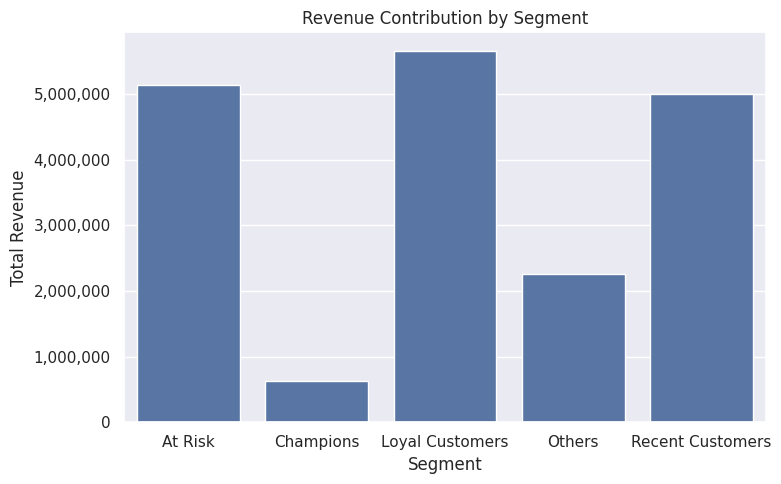

In [134]:
# Revenue/segment
plt.figure(figsize=(8,5))
sns.barplot(x=segment_revenue.index, y=segment_revenue.values)

plt.title("Revenue Contribution by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Revenue")

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()


**Insight:**
- Sebagian besar pelanggan berada dalam kategori “Others”, yang menunjukkan mayoritas pelanggan belum memiliki tingkat loyalitas yang tinggi.
- Namun, kontribusi revenue terbesar berasal dari segmen “Champions” dan “Loyal Customers”, meskipun jumlahnya lebih sedikit.
- Di sisi lain, segmen “At Risk” menunjukkan potensi penurunan revenue di masa depan karena pelanggan mulai tidak aktif.

## Conclusion

1. Customer dengan Kontribusi Revenue Tertinggi: Berdasarkan analisis terhadap data periode 2017 - 2018, diketahui bahwa top 10 customers memberikan kontribusi revenue yang jauh lebih tinggi dibandingkan pelanggan lainnya. Jika dibandingkan dengan total revenue, kontribusi dari top customers mencapai persentase yang signifikan, menunjukkan bahwa sebagian kecil pelanggan memiliki dampak besar terhadap pendapatan perusahaan. Pola ini mengindikasikan adanya Pareto Principle (80/20 rule) dalam distribusi revenue. Perusahaan disarankan untuk memprioritaskan strategi customer retention, seperti program loyalitas, penawaran eksklusif, dan personalisasi layanan untuk mempertahankan pelanggan bernilai tinggi.

2. Tren Penjualan dari Waktu ke Waktu: Analisis tren revenue bulanan selama periode 2016 - 2018 menunjukkan adanya peningkatan yang konsisten dari waktu ke waktu. Puncak penjualan (peak) terjadi pada bulan dengan nilai revenue tertinggi, sementara penurunan terendah (lowest point) terjadi pada bulan dengan nilai transaksi paling kecil. Pola ini mengindikasikan adanya seasonality, di mana penjualan cenderung meningkat pada periode tertentu, khususnya menjelang akhir tahun. Perusahaan dapat memanfaatkan pola musiman ini dengan mengoptimalkan promosi pada periode peak dan menyusun strategi diskon atau campaign untuk meningkatkan penjualan saat low season.

3. Segmentasi Pelanggan Berdasarkan RFM: Hasil segmentasi pelanggan menggunakan metode RFM (Recency, Frequency, Monetary) menunjukkan bahwa sebagian besar pelanggan berada dalam kategori “Others”, yang berarti belum memiliki tingkat loyalitas yang tinggi. Namun, segmen “Champions” dan “Loyal Customers” memberikan kontribusi revenue terbesar dibandingkan segmen lainnya. Di sisi lain, terdapat segmen “At Risk” yang berpotensi berhenti melakukan transaksi di masa depan. Strategi pemasaran dapat difokuskan sebagai berikut:

    a. Champions & Loyal Customers → dipertahankan dengan reward dan loyalty program

    b. At Risk → dilakukan re-engagement (diskon, email campaign, dll)
    
    c. Others → ditingkatkan engagement untuk mendorong repeat purchase
